# Experiment #2: Linear Regression Models to Predict Maximum Heart Rate (thalach)

**Dataset:** Heart Disease (UCI) - `heart.csv`  


## 0. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load the Dataset

In [2]:
df = pd.read_csv('heart.csv')
print('Shape:', df.shape)
df.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 2. Dataset Information (rows, columns, data types, missing values)

In [3]:
print('Rows:', df.shape[0], '| Columns:', df.shape[1])
df.info()
print('\nMissing values per column:')
print(df.isna().sum()[df.isna().sum() > 0].to_string() if df.isna().any().any() else 'No missing values.')

print('\nSummary statistics:')
df.describe()

Rows: 303 | Columns: 14
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

Missing values per column:
No missing values.

Summary statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## 3. Preprocessing: Handle Missing Values and Duplicates

The dataset has no missing values, but there is one duplicate row which we remove.


In [4]:
print('Missing values total:', df.isna().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
df = df.drop_duplicates()
print('Shape after removing duplicates:', df.shape)

Missing values total: 0
Duplicate rows: 1
Shape after removing duplicates: (302, 14)


## 4. Preprocessing: Outlier Detection (Box Plots)

We check the numeric features used in the models (`age`, `trestbps`, `chol`) and the target (`thalach`) for outliers using the IQR method.


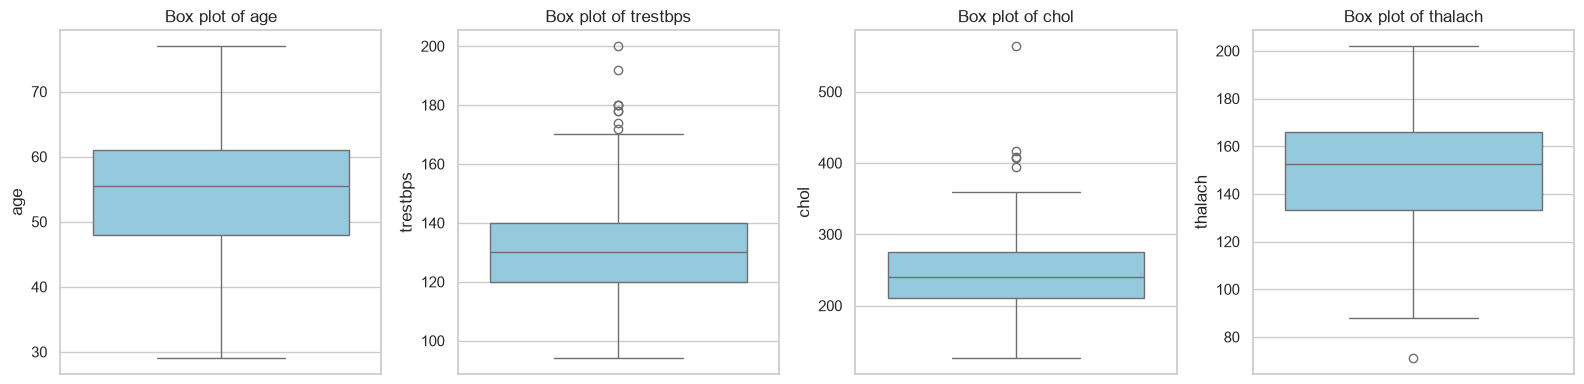

,IQR outliers
age,0
trestbps,9
chol,5
thalach,1


In [5]:
cols = ['age', 'trestbps', 'chol', 'thalach']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, c in zip(axes, cols):
    sns.boxplot(y=df[c], ax=ax, color='skyblue')
    ax.set_title(f'Box plot of {c}')
plt.tight_layout()
plt.show()

def count_iqr_outliers(s):
    Q1, Q3 = s.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    return int(((s < Q1 - 1.5 * IQR) | (s > Q3 + 1.5 * IQR)).sum())

pd.DataFrame({'IQR outliers': [count_iqr_outliers(df[c]) for c in cols]}, index=cols)

---
## PART A: Simple Linear Regression (age -> thalach)

**Objective:** Build a simple linear regression model using `age` to predict `thalach`.

### A1. Prepare Features and Target

In [6]:
X = df[['age']]
y = df['thalach']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train size:', X_train.shape, '| Test size:', X_test.shape)

Train size: (241, 1) | Test size: (61, 1)


### A2. Train the Model and Compute Slope, Intercept, MSE

In [7]:
model_a = LinearRegression()
model_a.fit(X_train, y_train)
y_pred_a = model_a.predict(X_test)

slope = model_a.coef_[0]
intercept = model_a.intercept_
mse_a = mean_squared_error(y_test, y_pred_a)

print(f'Slope     : {slope:.4f}')
print(f'Intercept : {intercept:.4f}')
print(f'MSE       : {mse_a:.4f}')
print(f'Equation  : thalach = {slope:.3f} * age + {intercept:.3f}')

Slope     : -0.8977
Intercept : 198.5427
MSE       : 483.2875
Equation  : thalach = -0.898 * age + 198.543


### A3. Plot the Regression Line and Predicted Points

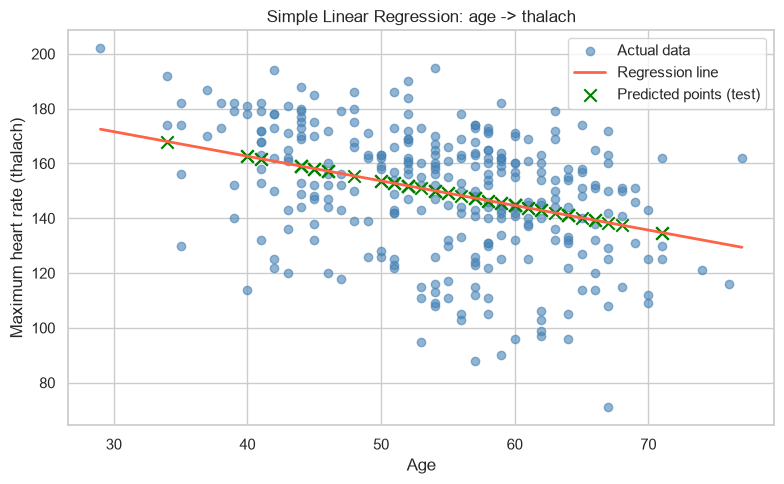

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(df['age'], df['thalach'], color='steelblue', alpha=0.6, label='Actual data')
age_range = np.linspace(df['age'].min(), df['age'].max(), 100)
plt.plot(age_range, model_a.predict(age_range.reshape(-1, 1)), color='tomato', linewidth=2, label='Regression line')
plt.scatter(X_test['age'], y_pred_a, color='green', marker='x', s=80, label='Predicted points (test)')
plt.xlabel('Age')
plt.ylabel('Maximum heart rate (thalach)')
plt.title('Simple Linear Regression: age -> thalach')
plt.legend()
plt.tight_layout()
plt.show()

---
## PART B: Multiple Linear Regression - Case 1

**Objective:** Predict `thalach` using 3 features: `age`, `trestbps`, `chol`.

### B1. Prepare the Feature Matrix

In [9]:
features_b = ['age', 'trestbps', 'chol']
X = df[features_b]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Feature matrix shape:', X_train.shape)

Feature matrix shape: (241, 3)


### B2. Train the Model and Compute Coefficients, Intercept, MSE

In [10]:
model_b = LinearRegression()
model_b.fit(X_train, y_train)
y_pred_b = model_b.predict(X_test)

mse_b = mean_squared_error(y_test, y_pred_b)
print('Coefficients:')
for f, c in zip(features_b, model_b.coef_):
    print(f'  {f:>9s} : {c:.4f}')
print(f'Intercept   : {model_b.intercept_:.4f}')
print(f'MSE         : {mse_b:.4f}')

Coefficients:
        age : -0.9993
   trestbps : 0.0507
       chol : 0.0564
Intercept   : 183.5127
MSE         : 502.8197


---
## PART C: Multiple Linear Regression - Case 2

**Objective:** Enhance the model with more clinical features: `age`, `trestbps`, `chol`, `sex`, `cp`, `fbs`, `exang`.

### C1. Prepare the Feature Matrix

In [11]:
features_c = ['age', 'trestbps', 'chol', 'sex', 'cp', 'fbs', 'exang']
X = df[features_c]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Feature matrix shape:', X_train.shape)

Feature matrix shape: (241, 7)


### C2. Train the Model and Compute Coefficients, Intercept, MSE

In [12]:
model_c = LinearRegression()
model_c.fit(X_train, y_train)
y_pred_c = model_c.predict(X_test)

mse_c = mean_squared_error(y_test, y_pred_c)
print('Coefficients:')
for f, c in zip(features_c, model_c.coef_):
    print(f'  {f:>9s} : {c:.4f}')
print(f'Intercept   : {model_c.intercept_:.4f}')
print(f'MSE         : {mse_c:.4f}')

Coefficients:
        age : -0.9035
   trestbps : 0.0502
       chol : 0.0597
        sex : -1.0628
         cp : 3.5968
        fbs : -0.1634
      exang : -14.1370
Intercept   : 178.9743
MSE         : 424.2325


---
## Comparison of the Three Models

In [13]:
comparison = pd.DataFrame({
    'Model': ['A: Simple (age)', 'B: Multiple (age, trestbps, chol)', 'C: Multiple (7 clinical features)'],
    'Features': ['age', 'age, trestbps, chol', 'age, trestbps, chol, sex, cp, fbs, exang'],
    'MSE': [round(mse_a, 2), round(mse_b, 2), round(mse_c, 2)],
})
display(comparison)
print('\nBest model (lowest MSE): Model', ['A', 'B', 'C'][comparison['MSE'].idxmin()], f"(MSE = {comparison['MSE'].min()})")

,Model,Features,MSE
0,A: Simple (age),age,483.29
1,"B: Multiple (age, trestbps, chol)","age, trestbps, chol",502.82
2,C: Multiple (7 clinical features),"age, trestbps, chol, sex, cp, fbs, exang",424.23



Best model (lowest MSE): Model C (MSE = 424.23)


---
## Inference & Reflection

**Which model had the best prediction?**

Model C (multiple linear regression with 7 clinical features) had the lowest MSE of **424.23**, making it the most accurate of the three. Model A (simple regression on age alone) came second with an MSE of **483.29**.

**How did adding more features affect MSE?**

- Moving from 1 feature (age) to 3 features (age, trestbps, chol) made the model **worse** (MSE increased from 483.29 to 502.82). This shows that not every feature is useful — `trestbps` and `chol` added noise rather than signal for predicting maximum heart rate.
- Adding the full clinical set (7 features) in Model C improved the prediction significantly (MSE dropped to 424.23). The categorical/binary features `sex`, `cp`, `fbs` and `exang` captured heart-condition information that `age`, `trestbps` and `chol` alone could not.

**Conclusion on feature selection:** more features help only when they are informative. Adding irrelevant features can reduce accuracy, so feature selection matters.

**How can these models assist in early risk detection for heart patients?**

Maximum heart rate (`thalach`) is a key indicator of cardiac fitness during stress tests. By predicting `thalach` from routine clinical measurements (age, blood pressure, cholesterol, chest pain type, etc.), these models allow a doctor to:

1. Detect patients whose predicted maximum heart rate is abnormally low **before** a full stress test, flagging them for earlier screening.
2. Quantify how strongly each factor (e.g. age, exercise-induced angina) affects heart rate capacity through the regression coefficients.
3. Use Model C's lower MSE to support more reliable risk estimation, enabling earlier intervention and better monitoring of heart-health risk.

---
**End of Experiment #2.**
